# Stochastic model using Kolmogorov equations

## Imports and definitions

In [2]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [3]:
#set serif font
plt.rcParams["font.family"]="serif"

In [4]:
R = 0.00888
K = 0.00772

In [5]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Setting up system of equations

In [6]:
#r matrix

def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

def rij(i, j, N, A):
    """value of element r_ij in the r matrix"""

    if i == 0:
        return 0
    elif j == i+1:
        return growthRate(i, N, A)
    elif i == j+1:
        return eatRate(i, N, A)
    elif i == j:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    else:
        return 0

def rMatrix(N, A):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N, A)
    return r_matrix

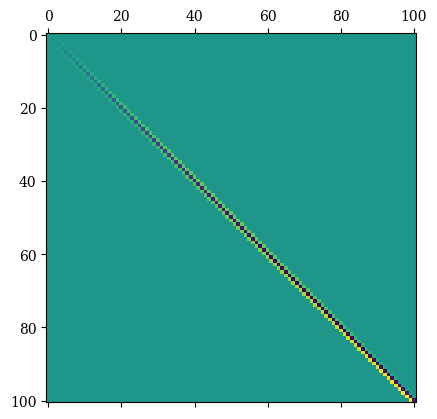

In [7]:
f, ax = plt.subplots()

ax.matshow(rMatrix(44, 100))

plt.show()

In [8]:
def simulate(N, A, stoptime, init):
    """return solution to kolmogorov equations given value for N, how long to simulate, and initial condition
    if init is "max", Ng(0) = A
    if init is "eq", Ng(0) is the equilibrium value from the deterministic model
    """
    #R matrix for give value of N
    r_matrix = rMatrix(N, A)

    #initial value
    p0 = np.zeros(A+1)
    if init == "max":
        p0[A]=1
    elif init == "eq":
        p0[int(A-N*R/K)]=1
    else:
        raise ValueError("init must be \"max\" or \"eq\"")

    #RHS of the system
    def sys(t, y):
        return np.matmul(y, r_matrix)
        
    st = time.time()
    
    s = sp.integrate.solve_ivp(sys, (0, stoptime), p0)
    
    print("finished solution N={0}, A={1}, Ng0 {2} in {3:.2f} seconds".format(N, A, init, time.time()-st))
    return s

## Execute simulations

## Save and load simulation results
because running the sims takes unpleasantly long

In [9]:
with open("kolmogorov_sol_max_100.dat", "rb") as f:
    sol_max_100 = pickle.load(f)

with open("kolmogorov_sol_eq_100.dat", "rb") as f:
    sol_eq_100 = pickle.load(f)

with open("kolmogorov_sol_max_500.dat", "rb") as f:
    sol_max_500 = pickle.load(f)

with open("kolmogorov_sol_eq_500.dat", "rb") as f:
    sol_eq_500 = pickle.load(f)

## Functions necessary for further investigation

In [10]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [11]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

## Plot evolution of probability distribution as a function of time

In [20]:
def evolutionPlot(a, sol, times):
    """on the axes a, plot the distribution of sol at times t
    returns list of line2ds representing plotted data
    """

    lines = []
    for i in times:
        lines.append(
            #append lines2d pointer to list
            a.plot(sol["y"][:,timeToIndex(sol["t"],i)],
            label="t={0:.0f}".format(sol["t"][timeToIndex(sol["t"],i)]))[0])
    return lines

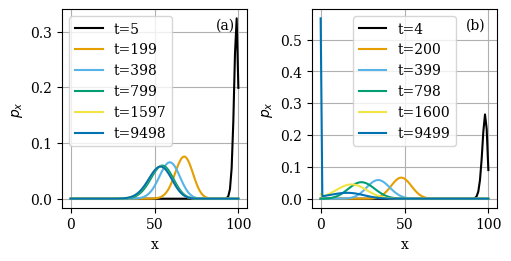

In [28]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 2.5), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

times = [5, 200, 400, 800, 1600, 9500]

evolutionPlot(ax1, sol_max_100["40"], times)
evolutionPlot(ax2, sol_max_100["70"], times)

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
    ax.set_xlabel("x")
    ax.set_ylabel("$p_x$")

plt.savefig("evolution.pdf")

## Plot expected value and variance as a function of time

In [14]:
def expPlot(a, sol):
    """plot expected value of sol as a function of time
    returns line2d representing the plotted data"""

    expval = np.array([
        pmfE(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], expval)

def varPlot(a, sol):
    """plot the variance of sol as a function of time
    returns line2d representing the plotted data"""

    vars = np.array([
        pmfVar(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], vars)

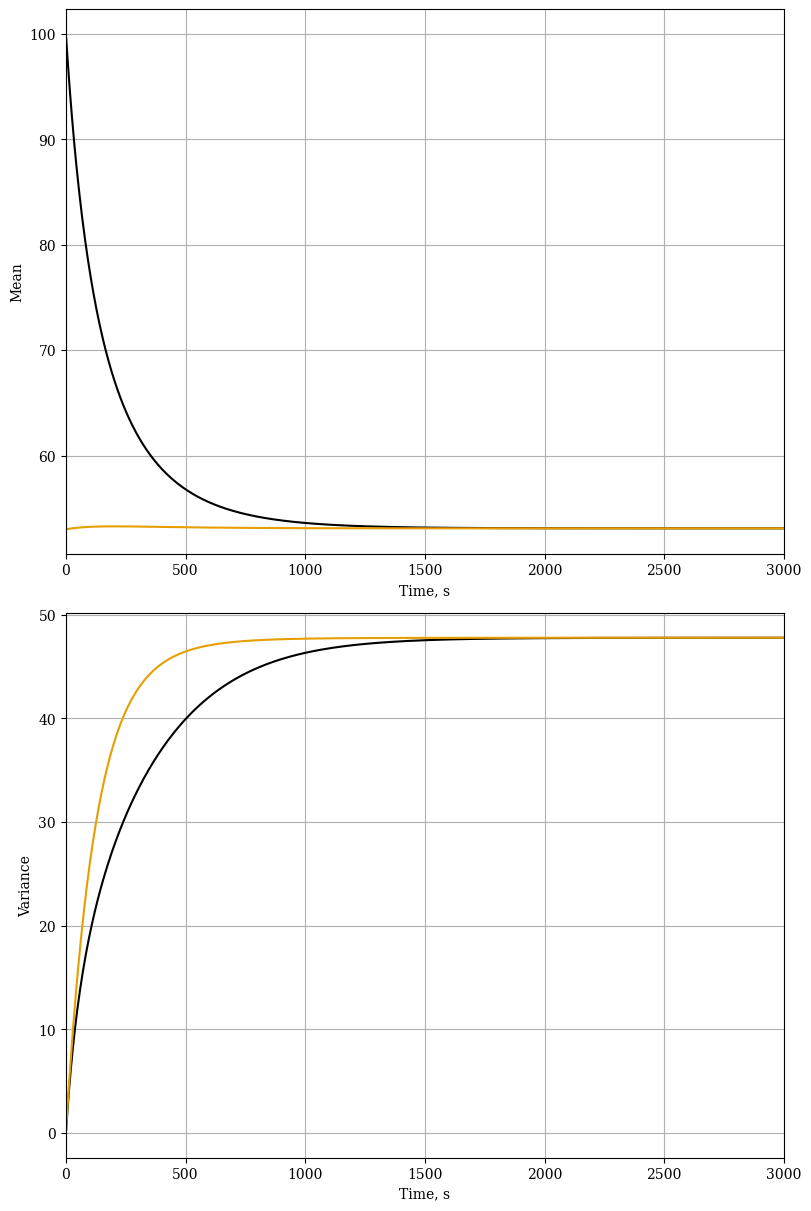

In [15]:
f, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 12), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

pt1 = expPlot(ax1, sol_max_100["40"])
pt2 = expPlot(ax1, sol_eq_100["40"])

pt3 = varPlot(ax2, sol_max_100["40"])
pt4 = varPlot(ax2, sol_eq_100["40"])

ax1.grid(True)
ax1.set_xlabel("Time, s")
ax1.set_ylabel("Mean")
ax1.set_xlim([0, 3000])

ax2.grid(True)
ax2.grid(True)
ax2.set_xlabel("Time, s")
ax2.set_ylabel("Variance")
ax2.set_xlim([0, 3000])

plt.show()

## Plot extinction probability as a function of time

In [16]:
def p0Plot(a, sol):
    return a.plot(sol["t"], sol["y"][0,:])

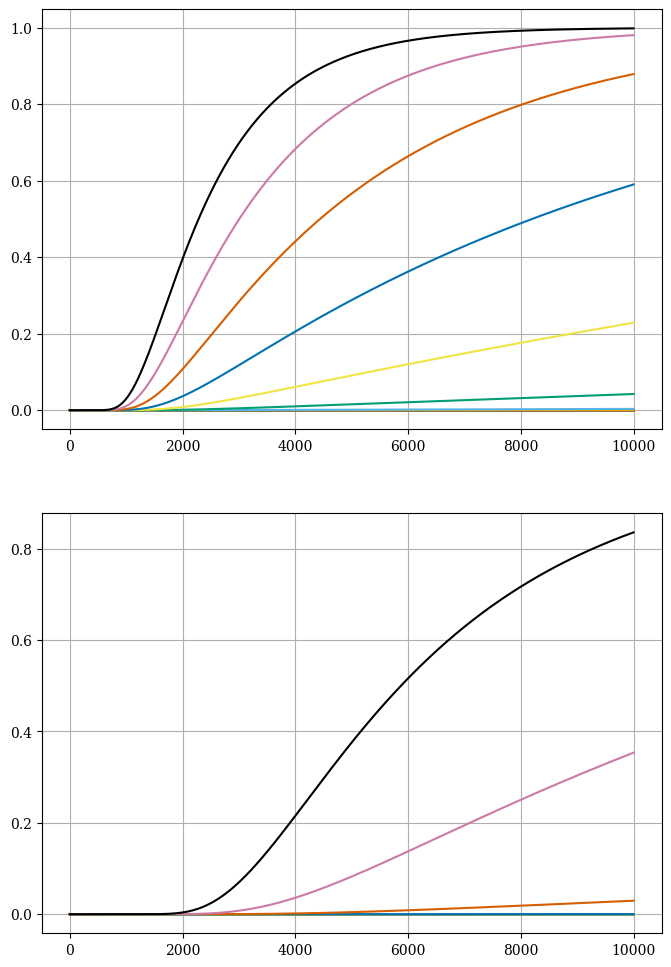

In [17]:
f, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 12))

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

for i in sol_max_100.keys():
    p0Plot(ax1, sol_max_100[i])

for i in sol_max_500.keys():
    p0Plot(ax2, sol_max_500[i])

ax1.grid(True)
ax2.grid(True)

#ax1.set_ylim([-0.001, 0.02])
#ax2.set_ylim([-0.001, 0.02])

plt.show()

## Plot equilibrium distribution for different sheep numbers

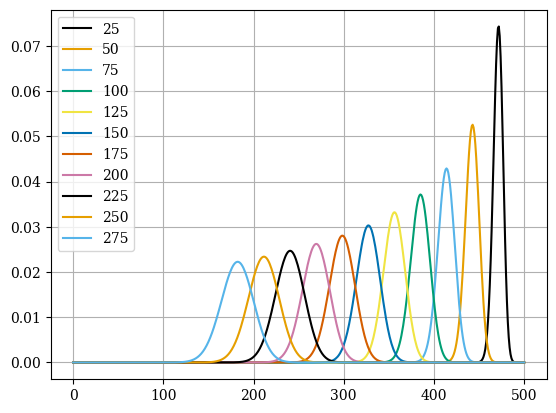

In [18]:
f, ax = plt.subplots()

ax.set_prop_cycle(wong_cycle)

for i in list(sol_eq_500.keys())[0:11]:
    ax.plot(sol_eq_500[i]["y"][:,-1], label=i)

ax.grid(True)
#ax.set_ylim([-0.01, 0.20])
ax.legend()

plt.show()

## Plot expected grass population after 10k seconds as a function of sheep number

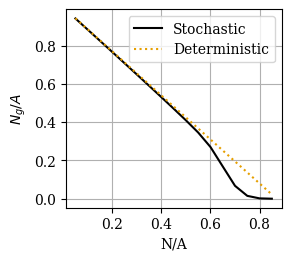

In [29]:
N_A = np.array([int(k) for k in list(sol_max_100.keys())])/100

det_N_g_100 = np.array(100 - N_A*R/K*100)/100

e_10k_100 = np.array([
    pmfE(sol_max_100[k]["y"][:,-1]) for k in list(sol_max_100.keys())
])/100

f, ax = plt.subplots(layout="constrained", figsize=(2.8, 2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(N_A, e_10k_100, "-", label="Stochastic")
ax.plot(N_A, det_N_g_100, ":", label="Deterministic")

ax.grid(True)
ax.legend()
ax.set_xlabel("N/A")
ax.set_ylabel("$N_g/A$")

plt.savefig("expected_N_g_vs_N.pdf")